# ===============================
# HEART DISEASE PREDICTION PROJECT
# ===============================

##1. DATA COLLECTION

**Dataset Name:** Heart Disease Dataset  
**Source:** Kaggle  
**Link:** https://www.kaggle.com  
**Number of Rows:** 1025  
**Number of Columns:** 14  

**Description:**  
This dataset contains medical attributes used to predict heart disease.

##2. DATA PREPROCESSING

#### 1. IMPORT LIBRARIES

In [47]:
# Data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


###### * Import necessary libraries for data analysis, visualization, and modeling.

####2. LOAD DATASET

In [49]:
# Load dataset (make sure file is in same directory)
df = pd.read_csv("heart.csv")

####3. DATA OVERVIEW

In [5]:
# Display first 5 rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
# Check number of rows and columns
df.shape

(1025, 14)

In [7]:
# Get basic information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [8]:
# Statistical summary numerical columns
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
# Display last 5 rows
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [10]:
# Here we print the name of all the coloumns of the dataset
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


####4. CHECK MISSING VALUES

In [11]:
# check missing values (True/False format for each cell)
df.isnull()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1021,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1022,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1023,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [12]:
# Checking missing values in each column
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


* No missing values found in the dataset, so no handling is required

* If missing values exist, we would handle them using mean/median/mode.


####5. OUTLIER DETECTION

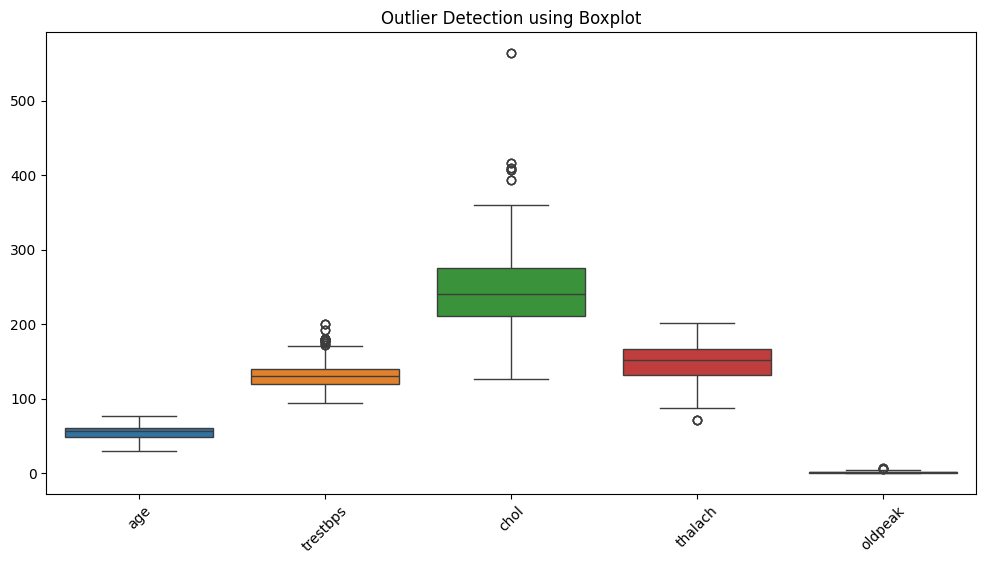

In [13]:
# Boxplot to visually detect outliers
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['age','trestbps','chol','thalach','oldpeak']])
plt.xticks(rotation=45)
plt.title("Outlier Detection using Boxplot")
plt.show()

######
* This code creates a boxplot to visualize and detect outliers in selected numerical features of the dataset.
* Outliers are present but not removed to preserve important medical information

####6. ENCODING CATEGORICAL DATA

######* Encoding is not required as all features are already numerical.


##3. EXPLORATORY DATA ANALYSIS (EDA)

In [14]:
# Target distribution
df['target'].value_counts()

,count
target,
1,526
0,499


In [15]:
# Sex distribution
df['sex'].value_counts()

,count
sex,
1,713
0,312


In [16]:
# Chest pain type distribution
df['cp'].value_counts()

,count
cp,
0,497
2,284
1,167
3,77


#### 1. DISTRIBUTION OF VARIABLES (HISTOGRAMS)

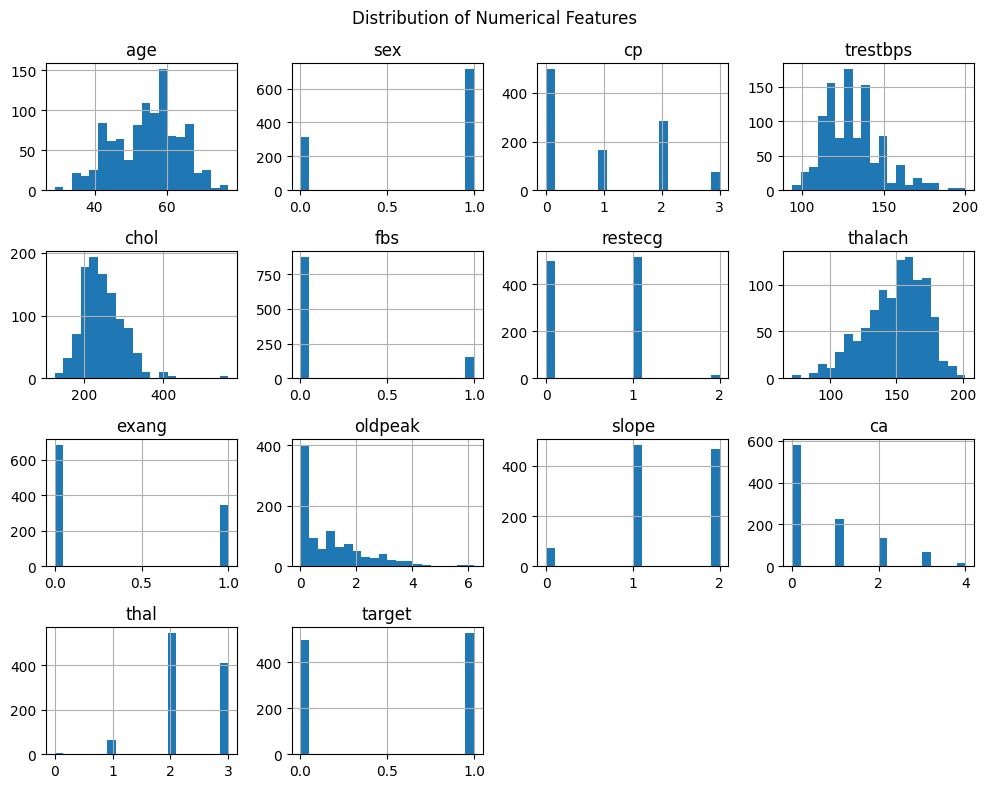

In [17]:
df.hist(figsize=(10,8), bins=20)
plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

###### * This code visualizes the frequency distribution of all numerical variables in the dataset using histograms.

####2. CORRELATION HEATMAP

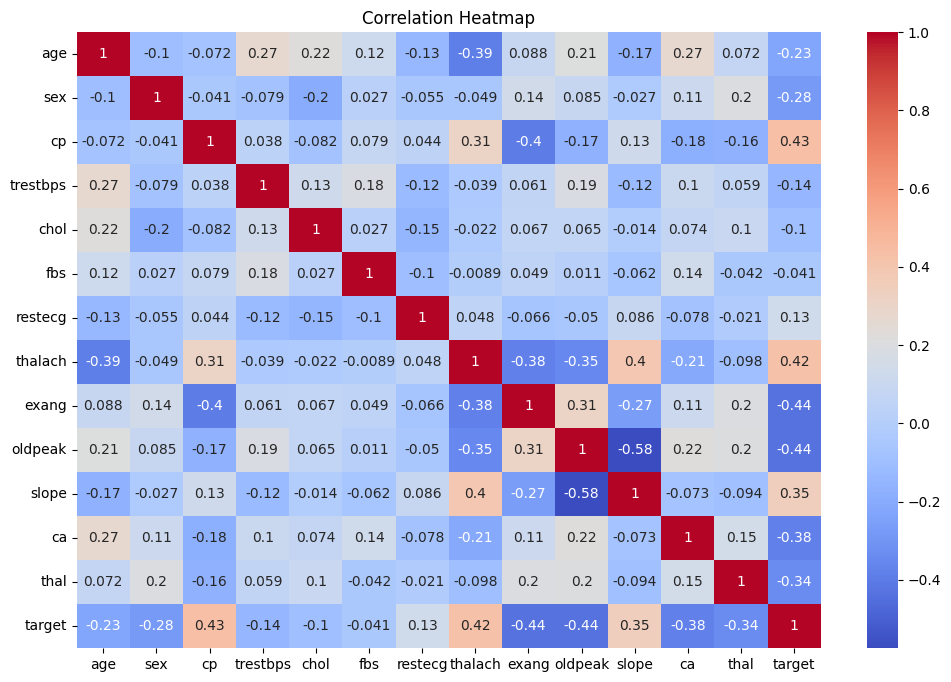

In [18]:

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

###### * Features like cp, thalach, and oldpeak show strong correlation with target, making them important for prediction.




####3. SCATTER PLOT (RELATIONSHIPS)

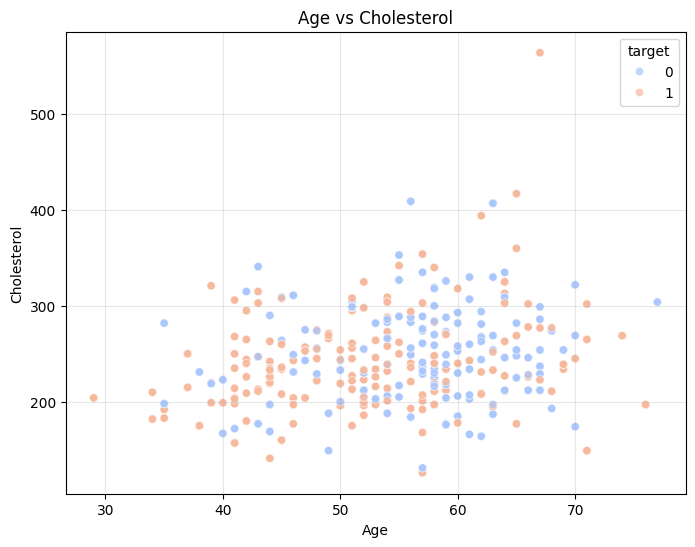

In [19]:
# relationship between age and cholesterol
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['age'], y=df['chol'], hue=df['target'], palette='coolwarm', alpha=0.7)
plt.title("Age vs Cholesterol")
plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.grid(True, alpha=0.3)
plt.show()

######
 * No strong linear relationship is observed between age and cholesterol, indicating weak correlation between these variables.


#### 4. TARGET VARIABLE DISTRIBUTION USING COUNTPLOT


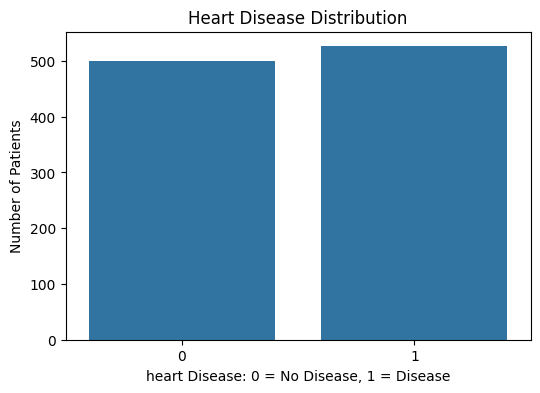

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["target"])
plt.title("Heart Disease Distribution")
plt.xlabel("heart Disease: 0 = No Disease, 1 = Disease")
plt.ylabel("Number of Patients")
plt.show()

######
* The dataset is fairly balanced.
* There are 517 patients with heart disease and 492 patients without heart disease.
* No major class imbalance problem.


##4. FEATURE ENGINEERING



####1. FEATURE CREATION

In [21]:
df["age_chol_ratio"] = df["age"] / (df["chol"] + 1)
df.head()   # Check result


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_chol_ratio
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,0.244131
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,0.259804
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,0.400000
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,0.299020
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,0.210169


* A new feature "age_chol_ratio" is created to capture the combined effect
  of age and cholesterol, which may improve model performance.

####2. FEATURE AND TARGET SPLIT

In [22]:
# Separate input features (X) and target variable (y)
# X = input features (independent variables)

# We remove the target column because the model should only learn from input features

X = df[['age','sex','cp','trestbps','chol','thalach','oldpeak']]

# y = output variable (dependent variable)
y = df["target"]     # y contains the target column (output)

print("Final Features Used:", X.columns)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Final Features Used: Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'thalach', 'oldpeak'], dtype='object')
Features shape: (1025, 7)
Target shape: (1025,)


######
* Dataset is split into features (X) including original + engineered features
* X contains all independent variables.
* y represents heart disease presence (0 = No, 1 = Yes).
* Data is now ready for model training.

In [ ]:
# Display first few rows of X
X.head()

,age,sex,cp,trestbps,chol,thalach,oldpeak
0,52,1,0,125,212,168,1.0
1,53,1,0,140,203,155,3.1
2,70,1,0,145,174,125,2.6
3,61,1,0,148,203,161,0.0
4,62,0,0,138,294,106,1.9


In [ ]:

# Display first few rows of y
y.head()

,target
0,0
1,0
2,0
3,0
4,0


##5. MODEL BUILDING


####1. TRAIN-TEST SPLIT

In [23]:
# Split dataset into training and testing sets (80% train, 20% test)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape, y_train.shape)

print("Testing set:", X_test.shape, y_test.shape)

Training set: (820, 7) (820,)
Testing set: (205, 7) (205,)


######
This step divides the dataset into:

* Training set (used to train the model)

* Testing set (used to evaluate performance)


####2. FEATURE SCALING

In [24]:
# Apply standardization to scale features
scaler = StandardScaler()

# Fit on training data and transform
X_train = scaler.fit_transform(X_train)

# Transform test data
X_test = scaler.transform(X_test)

######
* Feature scaling ensures all variables are on the same scale.
* This improves the performance of machine learning models.

### MODEL TRAINING

Three machine learning models were applied in this project:

1. Logistic Regression
2. Decision Tree
3. Random Forest

The dataset was divided into training and testing sets, and both models were trained using the training data.

####1. Logistic Regression

In [25]:

lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [26]:
lr_pred = lr.predict(X_test)

####2. Decision Tree

In [27]:

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [28]:
dt_pred = dt.predict(X_test)

####3. Random Forest

In [29]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [30]:

rf_pred = rf.predict(X_test)

####
Three different models are trained to compare performance:
- Logistic Regression (baseline model)
- Decision Tree (non-linear model)
- Random Forest (ensemble model)

##6. MODEL EVALUATION


###1. Accuracy Comparison

In [31]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.751219512195122
Decision Tree Accuracy: 1.0
Random Forest Accuracy: 1.0



####
* Best Model Selection

In [32]:



models = {
    "Logistic Regression": accuracy_score(y_test, lr_pred),
    "Decision Tree": accuracy_score(y_test, dt_pred),
    "Random Forest": accuracy_score(y_test, rf_pred)
}

best_model = max(models, key=models.get)
print("Best Model is:", best_model)

Best Model is: Decision Tree


###2. Confusion Matrix

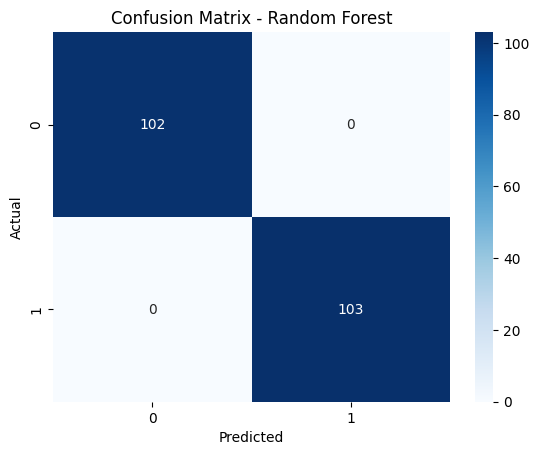

In [33]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

###3. Classification Report

In [34]:

print("Classification Report (Random Forest):")
print(classification_report(y_test, rf_pred))

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       102
           1       1.00      1.00      1.00       103

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



Evaluation metrics used:
- Accuracy: Overall correctness of the model
- Confusion Matrix: Detailed prediction breakdown
- Precision, Recall, F1-score: Performance for each class

In [35]:
import joblib

# Save model
joblib.dump(rf, "heart_model.pkl")

['heart_model.pkl']

In [36]:
# Save scaler
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
from google.colab import files

files.download("heart_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
